In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

Load Dataset

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
df.shape

(1470, 35)

In [7]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [8]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)*100
)

attrition_rate

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [41]:
categorical = X.select_dtypes(include="object").columns
numerical = X.select_dtypes(exclude="object").columns

print(categorical)
print(numerical)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [9]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(exclude=np.number).columns

print(len(num_cols))

print(len(cat_cols))

26
9


Observation

Around 16% of employees left while nearly 84% stayed. The dataset is imbalanced, meaning there are significantly fewer employees who left than those who stayed

____________________________________________________________


Data Cleaning

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [13]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [14]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [16]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")


Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [17]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"\nShape after One-Hot Encoding: {df.shape}")


Shape after One-Hot Encoding: (1470, 45)


In [18]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nPreprocessing complete")
print(f"Features: {X_scaled.shape[1]} | Samples: {X_scaled.shape[0]}")


Preprocessing complete
Features: 44 | Samples: 1470


EDA

In [22]:
df_eda = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [23]:
dept_attrition = df_eda.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
dept_attrition.columns = ['Department', 'Attrition Rate (%)']
print("\n1. Attrition Rate by Department:")
print(dept_attrition)



1. Attrition Rate by Department:
               Department  Attrition Rate (%)
0         Human Resources           19.047619
1  Research & Development           13.839750
2                   Sales           20.627803


In [24]:
role_attrition = df_eda.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
role_attrition.columns = ['JobRole', 'Attrition Rate (%)']
role_attrition = role_attrition.sort_values('Attrition Rate (%)', ascending=False)
print("\n2. Attrition Rate by Job Role:")
print(role_attrition)


2. Attrition Rate by Job Role:
                     JobRole  Attrition Rate (%)
8       Sales Representative           39.759036
2      Laboratory Technician           23.938224
1            Human Resources           23.076923
7            Sales Executive           17.484663
6         Research Scientist           16.095890
4     Manufacturing Director            6.896552
0  Healthcare Representative            6.870229
3                    Manager            4.901961
5          Research Director            2.500000


In [25]:
print("\n3. Avg Monthly Income — Left vs Stayed:")
print(df_eda.groupby('Attrition')['MonthlyIncome'].mean())


3. Avg Monthly Income — Left vs Stayed:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [26]:
print("\n4. Attrition Rate by Work-Life Balance Rating:")
wlb = df_eda.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100)
print(wlb)


4. Attrition Rate by Work-Life Balance Rating:
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [27]:
print("\n5. Attrition Rate by Years at Company (top 10):")
yac = df_eda.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False).head(10)
print(yac)


5. Attrition Rate by Years at Company (top 10):
YearsAtCompany
40    100.000000
23     50.000000
0      36.363636
1      34.502924
32     33.333333
31     33.333333
2      21.259843
33     20.000000
4      17.272727
24     16.666667
Name: Attrition, dtype: float64


Business Insights:
1. The department with the highest turnover rate is the sales department (approx. 21%).
2. Sales Representatives have the highest role turnover (approx. 40%).
3. The people who have left make approx. ₹4,800 per month less than those who are still with the organization.
4. People who scored low in Work-Life Balance (rating of 1) leave with an 31% attrition rate while others leave at an average of 16%.
5. Employees with experience of 0 to 1 year have the highest attrition.

Fixing error


In [31]:
print(df["Attrition"].head(10))
print(df["Attrition"].unique())
print(df["Attrition"].value_counts(dropna=False))


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Attrition, dtype: float64
[nan]
Attrition
NaN    1470
Name: count, dtype: int64


In [32]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [33]:
df["Attrition"].head()

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No


In [34]:
df["Attrition"] = df["Attrition"].replace({
    "Yes": 1,
    "No": 0
})

/tmp/ipykernel_1757/2270833986.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Attrition"] = df["Attrition"].replace({


In [35]:
print(df["Attrition"].unique())
print(df["Attrition"].isnull().sum())

[1 0]
0


In [36]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

Error fixed

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ]
)

In [43]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

In [44]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

Model Evaluation

In [45]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.340909,0.638298,0.444444,0.798260
1,Random Forest,0.750000,0.127660,0.218182,0.793651
2,Gradient Boosting,0.666667,0.212766,0.322581,0.796968


In [46]:
best_model = models["Logistic Regression"]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.83       247
           1       0.34      0.64      0.44        47

    accuracy                           0.74       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.83      0.74      0.77       294



Visualization

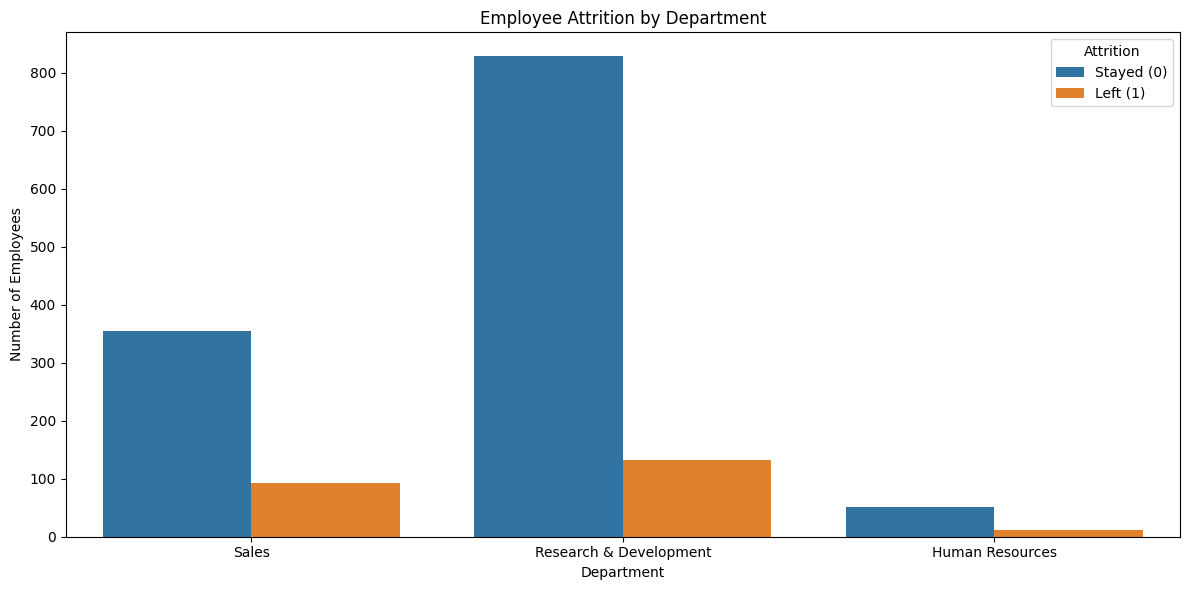

In [57]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stayed (0)", "Left (1)"])

plt.tight_layout()
plt.savefig("charts/chart1_department.png", dpi=300)
plt.show()

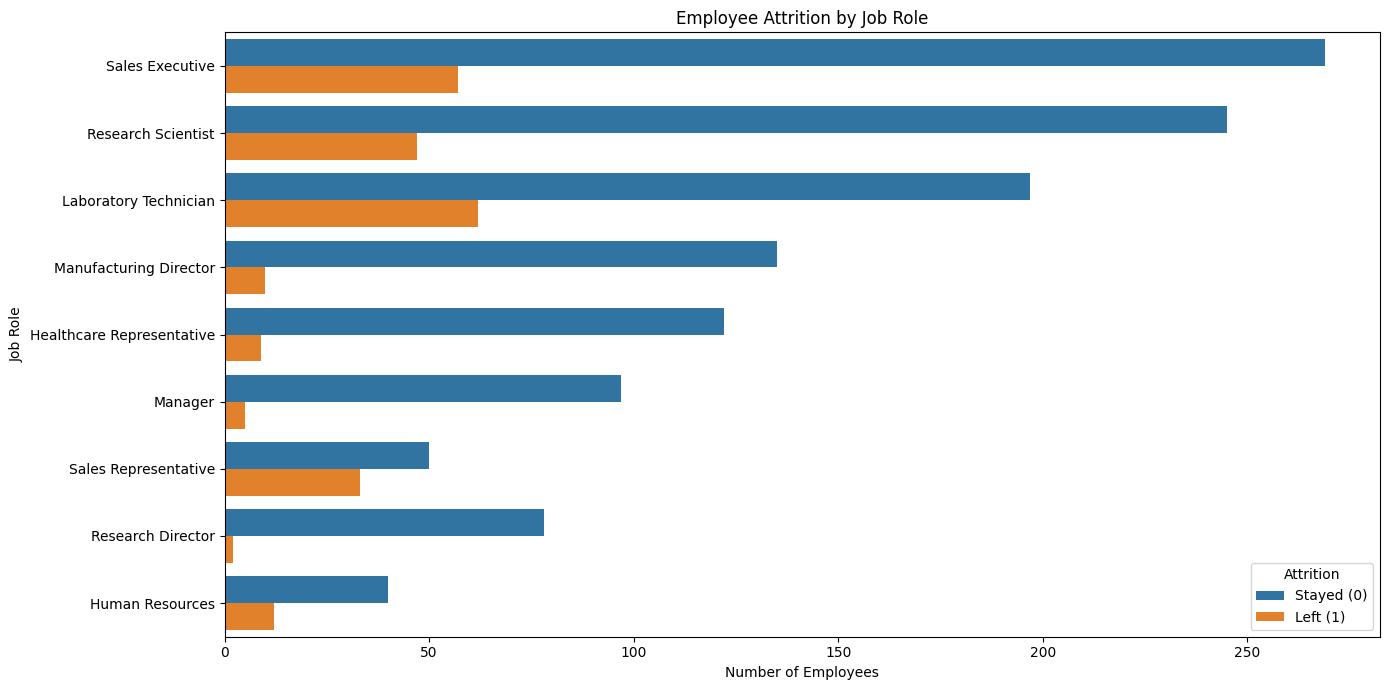

In [58]:
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    order=df["JobRole"].value_counts().index
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.legend(title="Attrition", labels=["Stayed (0)", "Left (1)"])

plt.tight_layout()
plt.savefig("charts/chart1_jobrole.png", dpi=300)
plt.show()

In [49]:
import os

os.makedirs("charts", exist_ok=True)

In [50]:
plt.savefig("charts/chart3_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

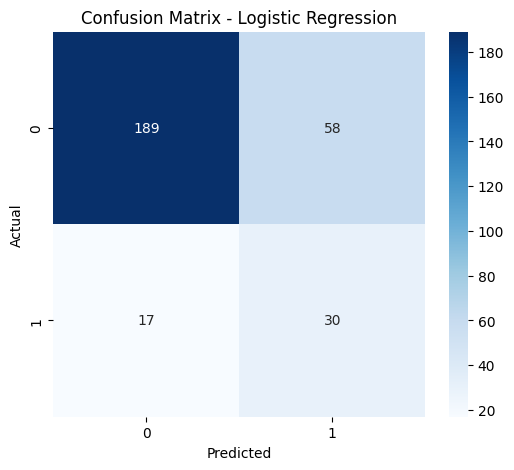

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/chart3_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()

coefficients = best_model.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(coefficients)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
45,cat__JobRole_Research Director,1.453283
42,cat__JobRole_Laboratory Technician,1.189714
48,cat__JobRole_Sales Representative,1.125726
26,cat__BusinessTravel_Non-Travel,0.989664
53,cat__OverTime_No,0.889372
36,cat__EducationField_Other,0.802424
27,cat__BusinessTravel_Travel_Frequently,0.790352
54,cat__OverTime_Yes,0.769604
32,cat__EducationField_Human Resources,0.697896
40,cat__JobRole_Healthcare Representative,0.652926


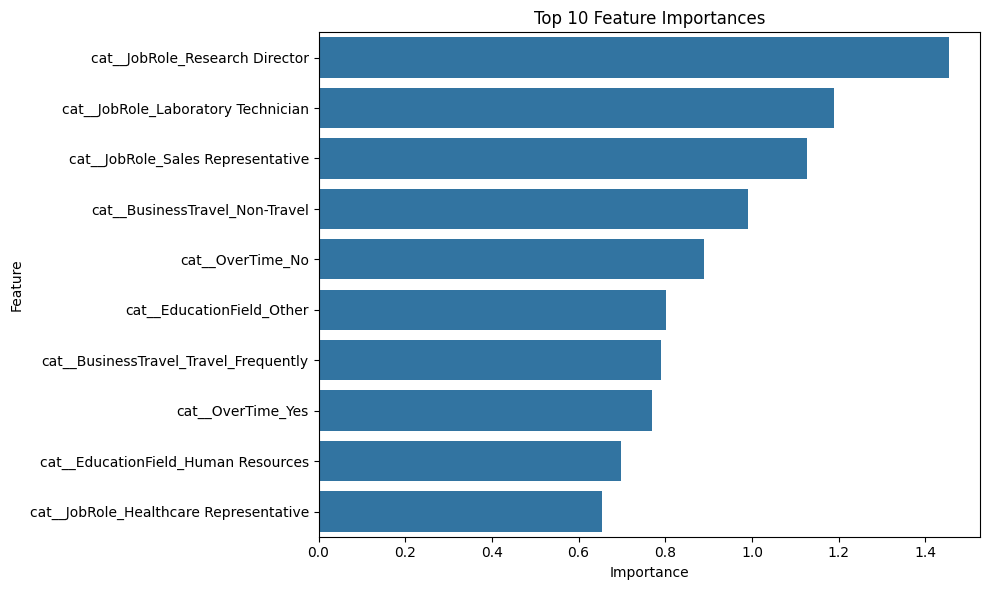

In [53]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("charts/chart4_feature_importance.png", dpi=300)

plt.show()

<Figure size 800x600 with 0 Axes>

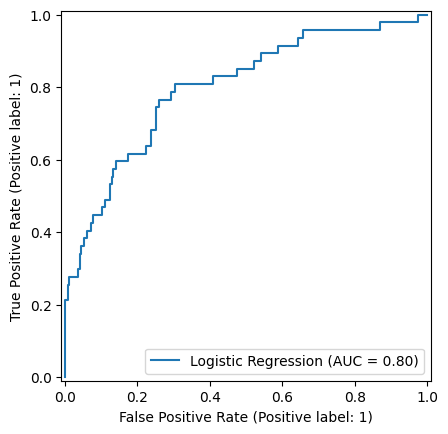

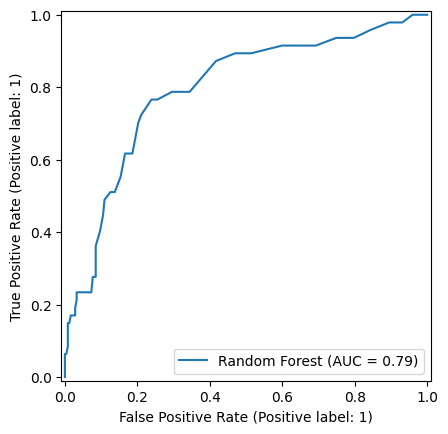

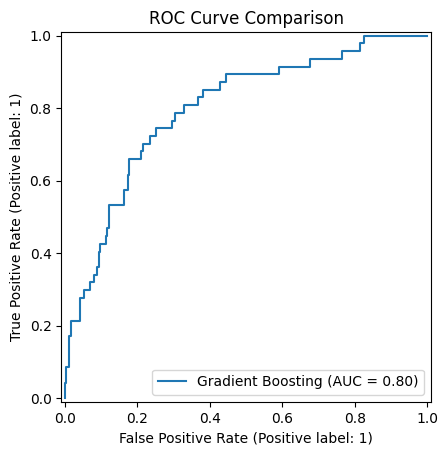

In [54]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("ROC Curve Comparison")
plt.savefig("charts/chart5_roc_curve.png", dpi=300)
plt.show()

In [55]:
results_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.340909,0.638298,0.444444,0.798260
1,Random Forest,0.750000,0.127660,0.218182,0.793651
2,Gradient Boosting,0.666667,0.212766,0.322581,0.796968


In [56]:
results_df.to_csv("model_comparison.csv", index=False)

HR Insights & Recommendations
According to the model, some of the key drivers of employee attrition include overtime, job satisfaction, and salary per month. Overtime, dissatisfaction, and low wages increase the risk of an employee leaving the organization.

Given the results of the exploratory analysis, it can be concluded that the Sales department and jobs such as Sales Representative should be considered for retaining employees since they have a higher attrition rate compared to others.

Not salary alone but other aspects of employment like work-life balance, career opportunities, and job satisfaction also influence why employees decide to leave the company.

In order to retain employees, the company should conduct regular conversations about retention with those who frequently work in overtime and provide career opportunities to at-risk employees.

One of the limitations of this model is that it uses only historical data about employees and does not take into account personal reasons or future organizational changes, which means that it can be used for informing HR decisions.